In [14]:
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\nMatches columns:\n", matches.columns.tolist())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [15]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [16]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [17]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [18]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [19]:
matches.drop(columns=['umpire1', 'umpire2'], inplace=True)

matches['city'].fillna('Unknown', inplace=True)
matches['winner'].fillna('No Result', inplace=True)
matches['player_of_match'].fillna('No Result', inplace=True)
matches['method'].fillna('Normal', inplace=True)

matches['date'] = pd.to_datetime(matches['date'])

matches['year'] = matches['date'].dt.year
matches['month'] = matches['date'].dt.month

print("Nulls remaining:\n", matches.isnull().sum())
print("\nCleaning done!")

Nulls remaining:
 id                  0
season              0
city                0
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
method              0
year                0
month               0
dtype: int64

Cleaning done!


/tmp/ipykernel_1251/2537140664.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1251/2537140664.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [20]:
print("Total matches:", len(matches))
print("Seasons covered:", sorted(matches['season'].unique()))
print("Total teams:", matches['team1'].nunique())

Total matches: 1095
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total teams: 19


In [21]:
import sqlite3

conn = sqlite3.connect("ipl.db")

matches.to_sql("matches", conn, if_exists="replace", index=False)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM matches")
print("Total rows in database:", cursor.fetchone()[0])

Total rows in database: 1095


In [22]:
query1 = pd.read_sql_query("""
    SELECT winner, COUNT(*) as total_wins
    FROM matches
    WHERE winner != 'No Result'
    GROUP BY winner
    ORDER BY total_wins DESC
    LIMIT 10
""", conn)

print(query1)

                        winner  total_wins
0               Mumbai Indians         144
1          Chennai Super Kings         138
2        Kolkata Knight Riders         131
3  Royal Challengers Bangalore         116
4             Rajasthan Royals         112
5          Sunrisers Hyderabad          88
6              Kings XI Punjab          88
7             Delhi Daredevils          67
8               Delhi Capitals          48
9              Deccan Chargers          29


In [23]:
query2 = pd.read_sql_query("""
    SELECT player_of_match, COUNT(*) as awards
    FROM matches
    WHERE player_of_match != 'No Result'
    GROUP BY player_of_match
    ORDER BY awards DESC
    LIMIT 10
""", conn)

print(query2)

  player_of_match  awards
0  AB de Villiers      25
1        CH Gayle      22
2       RG Sharma      19
3         V Kohli      18
4       DA Warner      18
5        MS Dhoni      17
6       YK Pathan      16
7       SR Watson      16
8       RA Jadeja      16
9       SP Narine      15


In [24]:
query3 = pd.read_sql_query("""
    SELECT toss_decision, COUNT(*) as count
    FROM matches
    GROUP BY toss_decision
""", conn)

print(query3)

  toss_decision  count
0           bat    391
1         field    704


In [25]:
query4 = pd.read_sql_query("""
    SELECT season, COUNT(*) as total_matches
    FROM matches
    GROUP BY season
    ORDER BY season ASC
""", conn)

print(query4)

     season  total_matches
0   2007/08             58
1      2009             57
2   2009/10             60
3      2011             73
4      2012             74
5      2013             76
6      2014             60
7      2015             59
8      2016             60
9      2017             59
10     2018             60
11     2019             60
12  2020/21             60
13     2021             60
14     2022             74
15     2023             74
16     2024             71


In [27]:
deliveries.to_sql("deliveries", conn, if_exists="replace", index=False)
print("Deliveries loaded!")
print("Columns:", deliveries.columns.tolist())

Deliveries loaded!
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [28]:
query5 = pd.read_sql_query("""
    SELECT bowler, COUNT(*) as total_wickets
    FROM deliveries
    WHERE is_wicket = 1
    AND dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
    GROUP BY bowler
    ORDER BY total_wickets DESC
    LIMIT 10
""", conn)

print(query5)

       bowler  total_wickets
0   YS Chahal            205
1   PP Chawla            192
2    DJ Bravo            183
3     B Kumar            181
4   SP Narine            180
5    R Ashwin            180
6    A Mishra            174
7  SL Malinga            170
8   JJ Bumrah            168
9   RA Jadeja            160


In [29]:
query6 = pd.read_sql_query("""
    SELECT bowler,
           COUNT(*) as balls_bowled,
           SUM(total_runs) as runs_given,
           ROUND(SUM(total_runs) * 6.0 / COUNT(*), 2) as economy_rate
    FROM deliveries
    GROUP BY bowler
    HAVING balls_bowled >= 500
    ORDER BY economy_rate ASC
    LIMIT 10
""", conn)

print(query6)

           bowler  balls_bowled  runs_given  economy_rate
0        A Kumble           983        1089          6.65
1  M Muralitharan          1581        1765          6.70
2       SP Narine          4146        4672          6.76
3        DW Steyn          2282        2583          6.79
4      DL Vettori           785         894          6.83
5     Rashid Khan          2901        3340          6.91
6         J Botha           709         818          6.92
7        R Ashwin          4679        5435          6.97
8          MM Ali           770         900          7.01
9      SL Malinga          2974        3486          7.03


In [30]:
query7 = pd.read_sql_query("""
    SELECT bowler, COUNT(*) as dot_balls
    FROM deliveries
    WHERE total_runs = 0
    GROUP BY bowler
    ORDER BY dot_balls DESC
    LIMIT 10
""", conn)

print(query7)

            bowler  dot_balls
0          B Kumar       1632
1        SP Narine       1569
2         R Ashwin       1552
3        PP Chawla       1325
4  Harbhajan Singh       1263
5        JJ Bumrah       1228
6        RA Jadeja       1216
7        YS Chahal       1194
8         UT Yadav       1186
9         A Mishra       1185


In [31]:
query8 = pd.read_sql_query("""
    SELECT dismissal_kind, COUNT(*) as total
    FROM deliveries
    WHERE is_wicket = 1
    AND dismissal_kind != ''
    GROUP BY dismissal_kind
    ORDER BY total DESC
""", conn)

print(query8)

          dismissal_kind  total
0                 caught   8063
1                 bowled   2212
2                run out   1114
3                    lbw    800
4      caught and bowled    367
5                stumped    358
6           retired hurt     15
7             hit wicket     15
8            retired out      3
9  obstructing the field      3


In [32]:
query9 = pd.read_sql_query("""
    SELECT bowler,
           SUM(CASE WHEN extras_type = 'wides' THEN 1 ELSE 0 END) as wides,
           SUM(CASE WHEN extras_type = 'noballs' THEN 1 ELSE 0 END) as no_balls,
           SUM(CASE WHEN extras_type IN ('wides', 'noballs') THEN 1 ELSE 0 END) as total_extras
    FROM deliveries
    GROUP BY bowler
    ORDER BY total_extras DESC
    LIMIT 10
""", conn)

print(query9)

           bowler  wides  no_balls  total_extras
0        DJ Bravo    167         9           176
1        R Ashwin    151         4           155
2         B Kumar    138        12           150
3      SL Malinga    128        18           146
4        UT Yadav    110        23           133
5  Mohammed Siraj    115         8           123
6        HV Patel    106        16           122
7        I Sharma     97        23           120
8       SN Thakur    103        10           113
9         P Kumar    112         1           113


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Chart style set!")

Chart style set!


/tmp/ipykernel_1251/715551863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=query1, x='total_wins', y='winner', palette='OrRd_r')


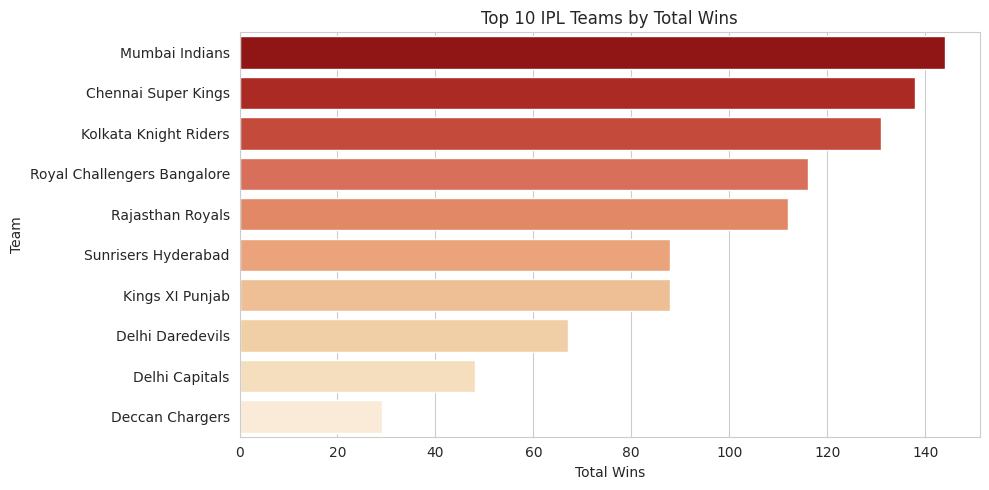

In [36]:
plt.figure()
sns.barplot(data=query1, x='total_wins', y='winner', palette='OrRd_r')
plt.title('Top 10 IPL Teams by Total Wins')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1251/3598299503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=query5, x='total_wickets', y='bowler', palette='Blues_r')


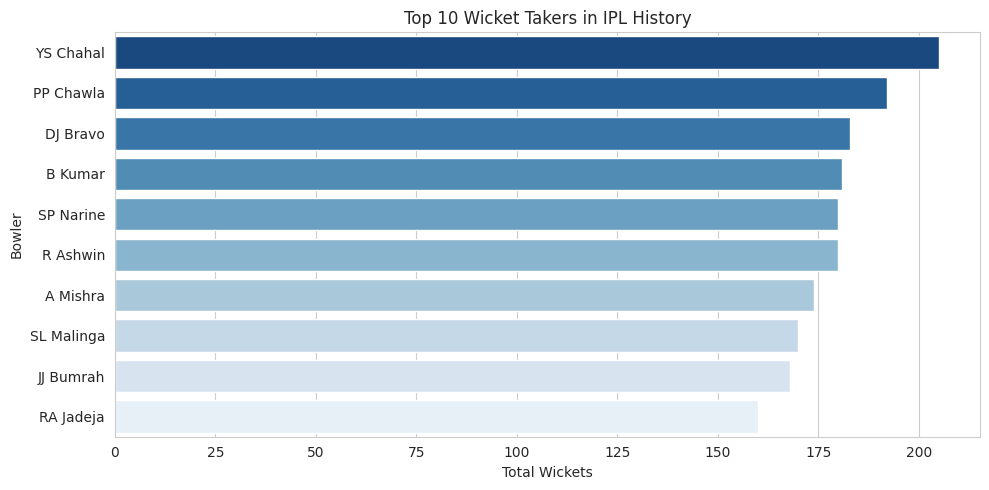

In [37]:
plt.figure()
sns.barplot(data=query5, x='total_wickets', y='bowler', palette='Blues_r')
plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

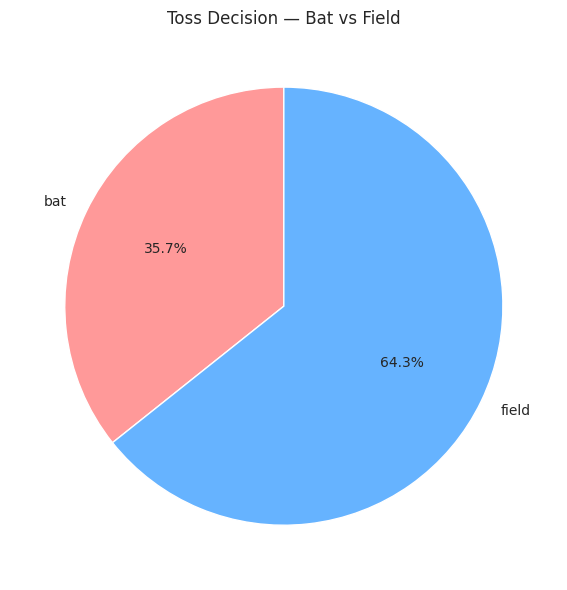

In [38]:
plt.figure(figsize=(6,6))
plt.pie(query3['count'], labels=query3['toss_decision'],
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff'],
        startangle=90)
plt.title('Toss Decision — Bat vs Field')
plt.tight_layout()
plt.show()

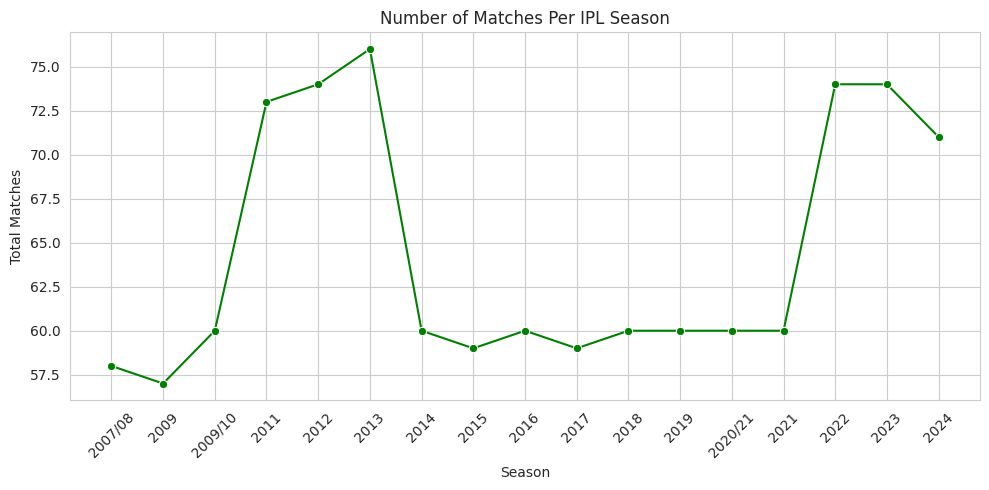

In [39]:
plt.figure()
sns.lineplot(data=query4, x='season', y='total_matches',
             marker='o', color='green')
plt.title('Number of Matches Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Total Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Export cleaned matches data
matches.to_excel("ipl_analysis.xlsx", sheet_name="Matches", index=False)

print("Exported to Excel!")

Exported to Excel!


In [42]:
from google.colab import files
files.download("ipl_analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>